In [1]:
!pip install -q yfinance==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 7.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("yfinance:", yf.__version__)

pandas: 2.2.3
numpy: 2.1.3
yfinance: 1.5.2


In [4]:
STOCKS = [
    "NVDA",
    "AMD",
    "MSFT",
    "GOOGL",
    "META",
]

BENCHMARKS = [
    "SPY",
    "QQQ",
    "SMH",
]

TICKERS = STOCKS + BENCHMARKS

START_DATE = "2018-01-01"
END_DATE = "2026-08-24"

print(TICKERS)

['NVDA', 'AMD', 'MSFT', 'GOOGL', 'META', 'SPY', 'QQQ', 'SMH']


In [5]:
all_data = []

for ticker in TICKERS:
    df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        actions=False,
        progress=False,
        threads=False,
        multi_level_index=False,
    )

    if df.empty:
        raise ValueError(f"No data downloaded for {ticker}")

    df = df.reset_index()
    df["Ticker"] = ticker

    all_data.append(df)

market_data = pd.concat(
    all_data,
    ignore_index=True
)

market_data.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2018-01-02,4.922529,4.926233,4.802769,4.834375,355616000,NVDA
1,2018-01-03,5.246500,5.276873,5.031178,5.039820,914704000,NVDA
2,2018-01-04,5.274155,5.384285,5.251931,5.327738,583268000,NVDA
3,2018-01-05,5.318850,5.356136,5.212176,5.288972,580124000,NVDA
4,2018-01-08,5.481824,5.555902,5.397374,5.442315,881216000,NVDA


In [7]:
print("Rows:", len(market_data))
print("Columns:", market_data.shape[1])

print()
print(market_data.columns.tolist())

Rows: 17368
Columns: 7

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


In [8]:
market_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17368 entries, 0 to 17367
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    17368 non-null  datetime64[ns]
 1   Close   17368 non-null  float64       
 2   High    17368 non-null  float64       
 3   Low     17368 non-null  float64       
 4   Open    17368 non-null  float64       
 5   Volume  17368 non-null  int64         
 6   Ticker  17368 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 949.9+ KB


In [9]:
summary = (
    market_data
    .groupby("Ticker")
    .agg(
        rows=("Date", "count"),
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        missing_close=("Close", lambda x: x.isna().sum()),
        missing_volume=("Volume", lambda x: x.isna().sum()),
    )
)

summary

,rows,start_date,end_date,missing_close,missing_volume
Ticker,,,,,
AMD,2171,2018-01-02,2026-08-21,0,0
GOOGL,2171,2018-01-02,2026-08-21,0,0
META,2171,2018-01-02,2026-08-21,0,0
MSFT,2171,2018-01-02,2026-08-21,0,0
NVDA,2171,2018-01-02,2026-08-21,0,0
QQQ,2171,2018-01-02,2026-08-21,0,0
SMH,2171,2018-01-02,2026-08-21,0,0
SPY,2171,2018-01-02,2026-08-21,0,0


In [10]:
duplicates = market_data.duplicated(
    subset=["Ticker", "Date"]
).sum()

print("Duplicate ticker/date rows:", duplicates)

Duplicate ticker/date rows: 0


In [11]:
market_data.isna().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Ticker,0


In [12]:
df.fillna(0)

,Date,Close,High,Low,Open,Volume,Ticker
0,2018-01-02,46.743351,46.752664,45.770014,45.872471,8908600,SMH
1,2018-01-03,47.404663,47.441921,46.855125,46.934295,7617000,SMH
2,2018-01-04,47.646832,47.786546,47.255636,47.679431,6699600,SMH
3,2018-01-05,47.954205,48.145144,47.632863,47.823806,3584800,SMH
4,2018-01-08,48.284851,48.415249,47.819141,47.954197,2768400,SMH
...,...,...,...,...,...,...,...
2166,2026-08-17,594.070007,600.369995,591.500000,593.719971,7700500,SMH
2167,2026-08-18,569.770020,577.760010,562.630005,574.359985,11364400,SMH
2168,2026-08-19,560.919983,576.840027,556.320007,575.059998,8713300,SMH
2169,2026-08-20,562.650024,566.000000,557.260010,559.380005,6240600,SMH


In [13]:
invalid_high = (
    market_data["High"]
    <
    market_data[["Open", "Close", "Low"]].max(axis=1)
).sum()

invalid_low = (
    market_data["Low"]
    >
    market_data[["Open", "Close", "High"]].min(axis=1)
).sum()

negative_volume = (
    market_data["Volume"] < 0
).sum()

non_positive_close = (
    market_data["Close"] <= 0
).sum()

print("Invalid highs:", invalid_high)
print("Invalid lows:", invalid_low)
print("Negative volume:", negative_volume)
print("Non-positive close:", non_positive_close)

Invalid highs: 0
Invalid lows: 0
Negative volume: 0
Non-positive close: 0


In [14]:
market_data = (
    market_data
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

In [15]:
market_data[
    market_data["Ticker"] == "NVDA"
].head()

,Date,Close,High,Low,Open,Volume,Ticker
8684,2018-01-02,4.922529,4.926233,4.802769,4.834375,355616000,NVDA
8685,2018-01-03,5.246500,5.276873,5.031178,5.039820,914704000,NVDA
8686,2018-01-04,5.274155,5.384285,5.251931,5.327738,583268000,NVDA
8687,2018-01-05,5.318850,5.356136,5.212176,5.288972,580124000,NVDA
8688,2018-01-08,5.481824,5.555902,5.397374,5.442315,881216000,NVDA


In [16]:
market_data[
    market_data["Ticker"] == "NVDA"
].tail()

,Date,Close,High,Low,Open,Volume,Ticker
10850,2026-08-17,225.009995,227.919998,224.860001,225.979996,93678700,NVDA
10851,2026-08-18,219.740005,221.639999,218.690002,220.449997,103128200,NVDA
10852,2026-08-19,217.559998,222.869995,216.759995,221.669998,96797300,NVDA
10853,2026-08-20,216.850006,219.860001,215.660004,218.360001,92457000,NVDA
10854,2026-08-21,214.720001,218.740005,214.500000,218.419998,98545600,NVDA


In [17]:
market_data["Return_1D"] = (
    market_data
    .groupby("Ticker")["Close"]
    .transform(
        lambda prices:
        prices.pct_change(fill_method=None)
    )
)

In [18]:
market_data[
    market_data["Ticker"] == "NVDA"
][
    ["Date", "Ticker", "Close", "Return_1D"]
].head(10)

,Date,Ticker,Close,Return_1D
8684,2018-01-02,NVDA,4.922529,NaN
8685,2018-01-03,NVDA,5.246500,0.065814
8686,2018-01-04,NVDA,5.274155,0.005271
8687,2018-01-05,NVDA,5.318850,0.008474
8688,2018-01-08,NVDA,5.481824,0.030641
8689,2018-01-09,NVDA,5.480341,-0.000270
8690,2018-01-10,NVDA,5.523307,0.007840
8691,2018-01-11,NVDA,5.533185,0.001789
8692,2018-01-12,NVDA,5.506022,-0.004909
8693,2018-01-16,NVDA,5.435154,-0.012871


In [19]:
return_summary = (
    market_data
    .groupby("Ticker")["Return_1D"]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
)

return_summary

,mean,std,min,max
Ticker,,,,
AMD,0.002369,0.035778,-0.173144,0.238205
GOOGL,0.001054,0.019635,-0.116341,0.102244
META,0.000862,0.026188,-0.263901,0.232824
MSFT,0.001006,0.018379,-0.147391,0.155067
NVDA,0.002245,0.031760,-0.187559,0.243696
QQQ,0.000832,0.015034,-0.119788,0.120031
SMH,0.001393,0.022243,-0.144116,0.171603
SPY,0.000615,0.012026,-0.109424,0.105019


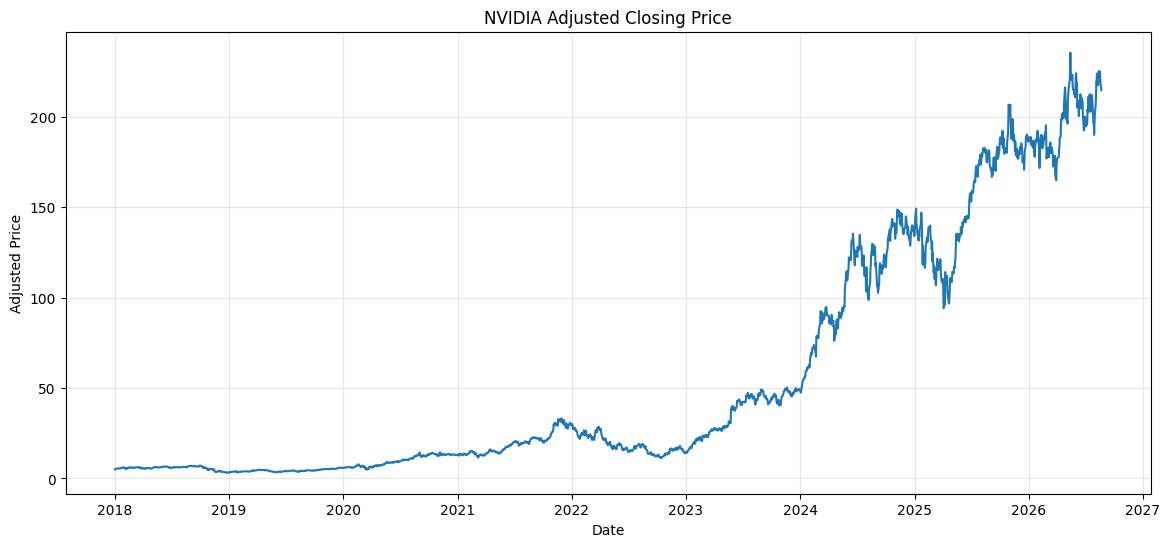

In [20]:
nvda = market_data[
    market_data["Ticker"] == "NVDA"
]

plt.figure(figsize=(14, 6))

plt.plot(
    nvda["Date"],
    nvda["Close"]
)

plt.title("NVIDIA Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.grid(alpha=0.3)

plt.show()

In [21]:
prices = (
    market_data
    .pivot(
        index="Date",
        columns="Ticker",
        values="Close"
    )
    .sort_index()
)

normalized_prices = (
    prices
    .div(prices.iloc[0])
    .mul(100)
)

normalized_prices.head()

Ticker,AMD,GOOGL,META,MSFT,NVDA,QQQ,SMH,SPY
Date,,,,,,,,
2018-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2018-01-03,105.191263,101.706101,101.791407,100.465357,106.581399,100.971685,101.414773,100.632522
2018-01-04,110.382517,102.101169,101.603991,101.349644,107.143197,101.148325,101.932854,101.056669
2018-01-05,108.196727,103.455061,102.993057,102.606184,108.051173,102.164163,102.590430,101.730106
2018-01-08,111.839711,103.820316,103.781286,102.710895,111.361948,102.561696,103.297795,101.916145


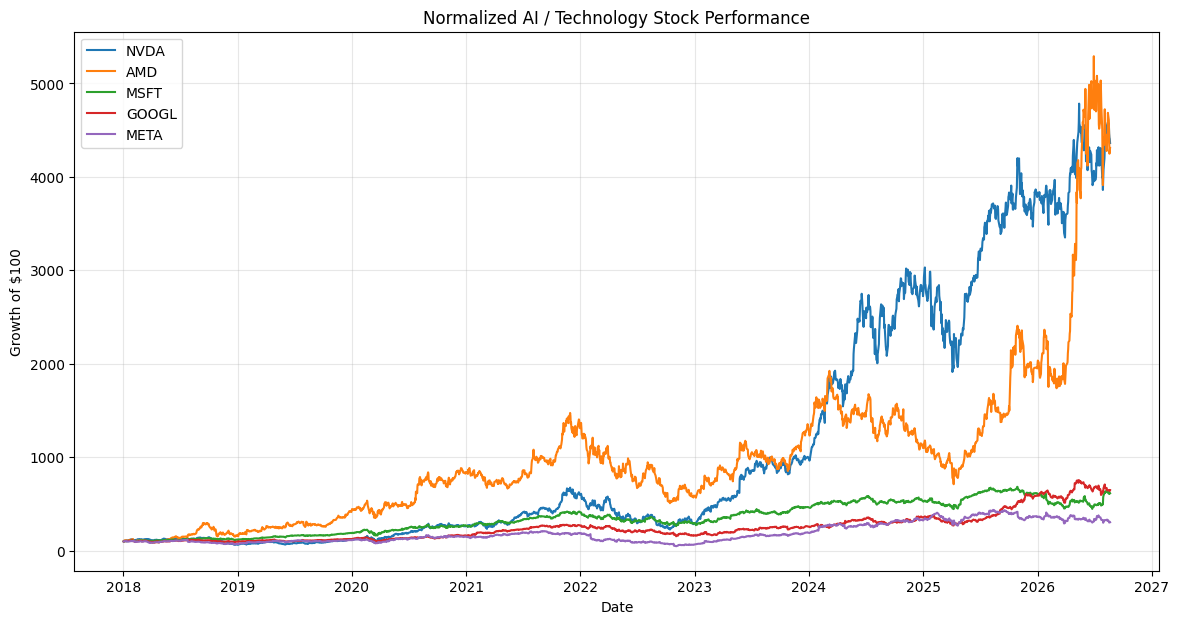

In [22]:
plt.figure(figsize=(14, 7))

for ticker in STOCKS:
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=ticker
    )

plt.title("Normalized AI / Technology Stock Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $100")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
from pathlib import Path

Path("data/raw").mkdir(
    parents=True,
    exist_ok=True
)

market_data.to_csv(
    "data/raw/market_data.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.
